# FX BARRIER OPTIONS - VALUATION ANALYSIS

Valuation and Risk of FX Barrier Options

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from financepy.utils.date import Date
from financepy.market.curves.flat_discount_curve import FlatDiscountCurve
from financepy.products.fx.fx_barrier_option import FXBarrierOption
from financepy.products.fx.fx_barrier_option import FXBarrierTypes
from financepy.models.black_scholes import BlackScholes
from financepy.utils.global_types import GBMNumericalSchemeTypes
from financepy.utils.global_types import ProcessTypes

#############################################################
#  FINANCEPY Version 1.1.2 - Built on 18 Sep 2026 at 20:26  #
#  This software is distributed FREE AND WITHOUT WARRANTY   #
#  Report issues at https://github.com/domokane/FinancePy   #
#############################################################



## Simple Example: Up and Out Call

This is an option whose that knocks out if the barrier is crossed from below. We're at maturity !

In [3]:
spot_fx_rate = 100.0
volatility = 0.20
dom_interest_rate = 0.05
for_interest_rate = 0.02


drift = dom_interest_rate - for_interest_rate
scheme = GBMNumericalSchemeTypes.ANTITHETIC
process_type = ProcessTypes.GBM_PROCESS

value_dt = Date(1, 1, 2015)
domestic_curve = FlatDiscountCurve(value_dt, dom_interest_rate)
foreign_curve = FlatDiscountCurve(value_dt, for_interest_rate)
model = BlackScholes(volatility)

num_observations = 100

Define the Option

In [4]:
notional = 100.0
currency_pair = "USDJPY"
notional_currency = "USD"
expiry_dt = Date(1, 1, 2016)
barrier_type = FXBarrierTypes.UP_AND_OUT_CALL
strike_price = 1.3
barrier_price = 1.45

In [5]:

fx_rates = np.linspace(1.2, 1.6, 200)

In [6]:
barrier_opt = FXBarrierOption(expiry_dt, strike_price, currency_pair, barrier_type, barrier_price, num_observations, notional, notional_currency)

In [7]:
print(barrier_opt)

OBJECT_TYPE: FXBarrierOption
EXPIRY DATE: 01-JAN-2016
STRIKE FX RATE: 1.3
CURRENCY PAIR: USDJPY
BARRIER TYPE: FXBarrierTypes.UP_AND_OUT_CALL
BARRIER LEVEL: 1.45
NUM OBSERVATIONS: 100
NOTIONAL: 100.0
NOTIONAL CURRENCY: USD


In [8]:
values = barrier_opt.value(value_dt, fx_rates, domestic_curve, foreign_curve, model)

Text(0, 0.5, 'Value')

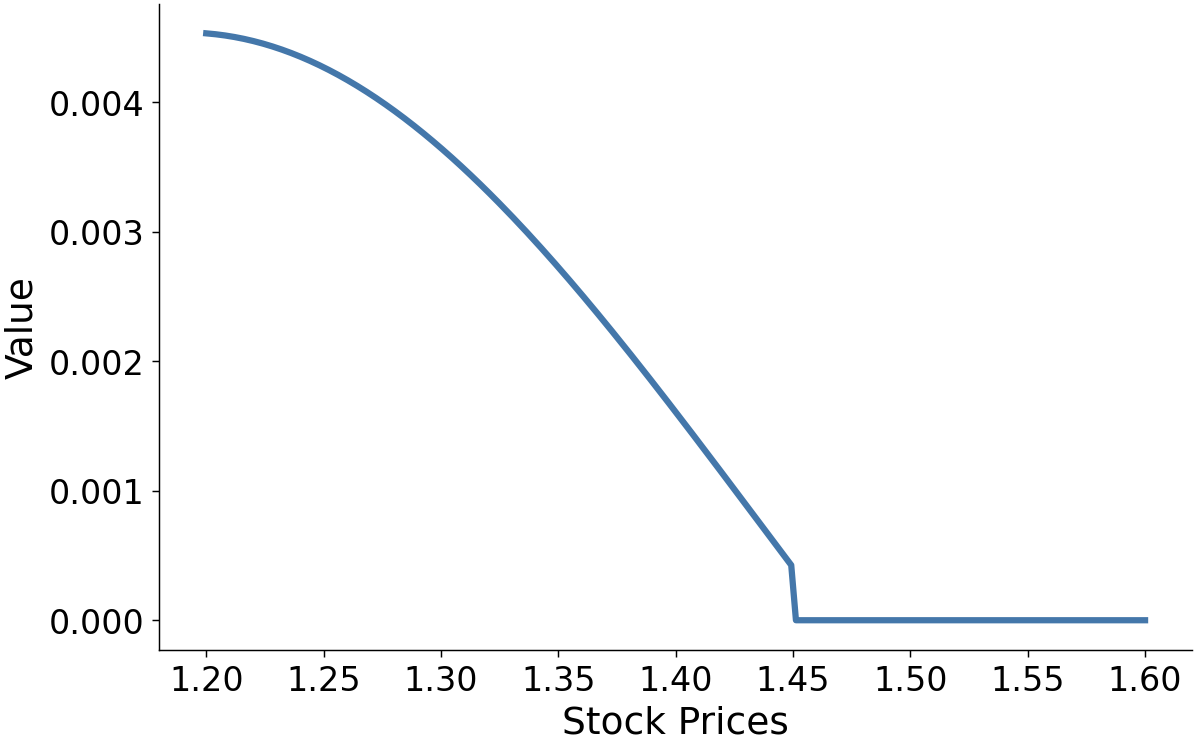

In [9]:
plt.figure(figsize=(8,5))
plt.plot(fx_rates, values)
plt.xlabel("Stock Prices")
plt.ylabel("Value")

Copyright (c) 2020 Dominic O'Kane